# Data Preprocessing and Dataset Alignment

**Focus:** Loading raw datasets, cleaning session records, aligning timestamps, and merging into a unified hourly schema.

**Datasets:**
- **ACN-Data** (Caltech): 16,304 EV charging sessions with timestamps, energy, station IDs
- **UrbanEV** (ST-EVCDP): 247 charging grids × 8,640 time intervals (5-min resolution)

In [16]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.utils import *
from src.preprocessing import *

setup_plot_style()

## Raw Data Ingestion

### 1.1 ACN-Data
Source: https://ev.caltech.edu/dataset.html
30,000+ sessions from Caltech & JPL charging stations

In [17]:
acn_raw = load_acn_data()
print(f"ACN Raw shape: {acn_raw.shape}")
print(f"\nColumn types:")
print(acn_raw.dtypes)
acn_raw.head()

2026-05-30 23:51:00 | preprocessing             | INFO    | Loading ACN data from CSV: c:\Users\USER\Desktop\Proj\notebooks\..\data\raw\acn_sessions.csv
2026-05-30 23:51:01 | preprocessing             | INFO    |   → Loaded 16304 raw ACN sessions, 21 columns


ACN Raw shape: (16304, 21)

Column types:
site                      str
_id                       str
clusterID             float64
connectionTime            str
disconnectTime            str
doneChargingTime          str
kWhDelivered          float64
sessionID                 str
siteID                float64
spaceID                   str
stationID                 str
timezone                  str
userID                float64
WhPerMile             float64
kWhRequested          float64
milesRequested        float64
minutesAvailable      float64
modifiedAt                str
paymentRequired        object
requestedDeparture        str
userID.1              float64
dtype: object


,site,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,...,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,caltech,5bc90cb9f9af8b0d7fe77cd2,39.0,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT","Wed, 25 Apr 2018 13:21:10 GMT",7.932,2_39_78_362_2018-04-25 11:08:04.400812,2.0,CA-496,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT","Wed, 25 Apr 2018 16:44:15 GMT",10.013,2_39_95_27_2018-04-25 13:45:09.617470,2.0,CA-319,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT","Wed, 25 Apr 2018 14:51:44 GMT",5.257,2_39_79_380_2018-04-25 13:45:49.962001,2.0,CA-489,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,5bc90cb9f9af8b0d7fe77cd5,39.0,"Wed, 25 Apr 2018 14:37:06 GMT","Wed, 25 Apr 2018 23:55:34 GMT","Wed, 25 Apr 2018 16:05:22 GMT",5.177,2_39_79_379_2018-04-25 14:37:06.460772,2.0,CA-327,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,5bc90cb9f9af8b0d7fe77cd6,39.0,"Wed, 25 Apr 2018 14:40:34 GMT","Wed, 25 Apr 2018 23:03:12 GMT","Wed, 25 Apr 2018 17:40:30 GMT",10.119,2_39_79_381_2018-04-25 14:40:33.638896,2.0,CA-490,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Quick stats on ACN data
print(f"\nACN Data Summary:")
print(f"  Sessions: {len(acn_raw):,}")
print(f"  Stations: {acn_raw['stationID'].nunique() if 'stationID' in acn_raw.columns else 'N/A'}")
print(f"  Date range: {acn_raw['connectionTime'].min() if 'connectionTime' in acn_raw.columns else 'N/A'} to {acn_raw['connectionTime'].max() if 'connectionTime' in acn_raw.columns else 'N/A'}")
if 'kWhDelivered' in acn_raw.columns:
    print(f"  Energy range: {acn_raw['kWhDelivered'].min():.2f} - {acn_raw['kWhDelivered'].max():.2f} kWh")
    print(f"  Missing kWh: {acn_raw['kWhDelivered'].isna().sum()}")


ACN Data Summary:
  Sessions: 16,304
  Stations: 54
  Date range: Fri, 01 Jun 2018 00:00:40 GMT to Wed, 31 Oct 2018 23:39:41 GMT
  Energy range: 0.50 - 69.37 kWh
  Missing kWh: 1305


### 1.2 UrbanEV Data (ST-EVCDP)
Source: https://github.com/IntelligentSystemsLab/ST-EVCDP
247 charging grids in Shenzhen, China — 30 days at 5-minute intervals

In [19]:
urbanev_data = load_urbanev_data()

print("\nUrbanEV Components:")
for key, df in urbanev_data.items():
    print(f"  {key}: {df.shape}")

2026-05-30 23:51:01 | preprocessing             | INFO    | Loading UrbanEV data from c:\Users\USER\Desktop\Proj\notebooks\..\data\raw\urbanev
2026-05-30 23:51:01 | preprocessing             | INFO    |   Loaded time.csv: (8640, 6)
2026-05-30 23:51:04 | preprocessing             | INFO    |   Loaded volume.csv: (8640, 248)
2026-05-30 23:51:05 | preprocessing             | INFO    |   Loaded occupancy.csv: (8640, 248)
2026-05-30 23:51:06 | preprocessing             | INFO    |   Loaded price.csv: (8640, 248)
2026-05-30 23:51:07 | preprocessing             | INFO    |   Loaded duration.csv: (8640, 248)
2026-05-30 23:51:07 | preprocessing             | INFO    |   Loaded information.csv: (247, 10)
2026-05-30 23:51:07 | preprocessing             | INFO    |   Loaded stations.csv: (1706, 6)



UrbanEV Components:
  time: (8640, 6)
  volume: (8640, 248)
  occupancy: (8640, 248)
  price: (8640, 248)
  duration: (8640, 248)
  information: (247, 10)
  stations: (1706, 6)


In [20]:
# Inspect station/grid information
info = urbanev_data.get("information", pd.DataFrame())
if not info.empty:
    print(f"\nGrid Information:")
    print(f"  Total grids: {len(info)}")
    print(f"  Total chargers: {info['count'].sum() if 'count' in info.columns else 'N/A'}")
    print(f"  Fast chargers: {info['fast_count'].sum() if 'fast_count' in info.columns else 'N/A'}")
    print(f"  CBD grids: {info['CBD'].sum() if 'CBD' in info.columns else 'N/A'}")
    print(f"  Dynamic pricing grids: {info['dynamic_pricing'].sum() if 'dynamic_pricing' in info.columns else 'N/A'}")
    info.head()


Grid Information:
  Total grids: 247
  Total chargers: 18061
  Fast chargers: 2056
  CBD grids: 62
  Dynamic pricing grids: 57


## Initial Data Quality Diagnostics

In [21]:
data_quality_report(acn_raw, "ACN Raw Data")

2026-05-30 23:51:08 | utils                     | INFO    | 
  Data Quality Report: ACN Raw Data
  Shape: (16304, 21)
2026-05-30 23:51:08 | utils                     | INFO    | 
                      dtype  non_null  null_count  null_pct  unique                                  sample
site                    str         1       16303     99.99       1                                 caltech
_id                     str     14999        1305      8.00   14999                5bc90cb9f9af8b0d7fe77cd2
clusterID           float64     14999        1305      8.00       1                                    39.0
connectionTime          str     14999        1305      8.00   14964           Wed, 25 Apr 2018 11:08:04 GMT
disconnectTime          str     14999        1305      8.00   14970           Wed, 25 Apr 2018 13:20:10 GMT
doneChargingTime        str     14991        1313      8.05   14930           Wed, 25 Apr 2018 13:21:10 GMT
kWhDelivered        float64     14999        1305      8.00    96

,dtype,non_null,null_count,null_pct,unique,sample
site,str,1,16303,99.99,1,caltech
_id,str,14999,1305,8.00,14999,5bc90cb9f9af8b0d7fe77cd2
clusterID,float64,14999,1305,8.00,1,39.0
connectionTime,str,14999,1305,8.00,14964,"Wed, 25 Apr 2018 11:08:04 GMT"
disconnectTime,str,14999,1305,8.00,14970,"Wed, 25 Apr 2018 13:20:10 GMT"
doneChargingTime,str,14991,1313,8.05,14930,"Wed, 25 Apr 2018 13:21:10 GMT"
kWhDelivered,float64,14999,1305,8.00,9692,7.932
sessionID,str,14999,1305,8.00,14999,2_39_78_362_2018-04-25 11:08:04.400812
siteID,float64,14999,1305,8.00,1,2.0
spaceID,str,14999,1305,8.00,54,CA-496


## Data Cleaning and Filtering

### 3.1 Clean ACN Data
- Parse timestamps (connectionTime, disconnectTime, doneChargingTime)
- Compute session & charging duration
- Drop sessions with missing energy or invalid durations
- Standardize column names

In [22]:
acn_clean = clean_acn_data(acn_raw)
print(f"\nACN Clean shape: {acn_clean.shape}")
print(f"Columns: {list(acn_clean.columns)}")
acn_clean.head()

2026-05-30 23:51:08 | preprocessing             | INFO    | Cleaning ACN data...
2026-05-30 23:51:10 | preprocessing             | INFO    |   Dropped 1305 rows with missing kWhDelivered
2026-05-30 23:51:10 | preprocessing             | INFO    |   Removed 0 sessions with non-positive duration
2026-05-30 23:51:10 | preprocessing             | INFO    |   Removed 0 sessions with non-positive energy
2026-05-30 23:51:10 | preprocessing             | INFO    |   → Clean ACN data: (14999, 24)



ACN Clean shape: (14999, 24)
Columns: ['site', '_id', 'cluster_id', 'session_start', 'session_end', 'charging_end', 'energy_kwh', 'session_id', 'site_id', 'space_id', 'station_id', 'timezone', 'user_id', 'WhPerMile', 'kWhRequested', 'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'userID.1', 'session_duration_min', 'charging_duration_min', 'data_source']


,site,_id,cluster_id,session_start,session_end,charging_end,energy_kwh,session_id,site_id,space_id,...,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1,session_duration_min,charging_duration_min,data_source
0,caltech,5bc90cb9f9af8b0d7fe77cd2,39.0,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:21:10,7.932,2_39_78_362_2018-04-25 11:08:04.400812,2.0,CA-496,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132.100000,133.100000,ACN
1,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2.0,CA-319,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,671.100000,179.083333,ACN
2,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2.0,CA-489,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,558.916667,65.900000,ACN
3,NaN,5bc90cb9f9af8b0d7fe77cd5,39.0,2018-04-25 14:37:06,2018-04-25 23:55:34,2018-04-25 16:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2.0,CA-327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,558.466667,88.266667,ACN
4,NaN,5bc90cb9f9af8b0d7fe77cd6,39.0,2018-04-25 14:40:34,2018-04-25 23:03:12,2018-04-25 17:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2.0,CA-490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,502.633333,179.933333,ACN


In [23]:
data_quality_report(acn_clean, "ACN Cleaned")

2026-05-30 23:51:10 | utils                     | INFO    | 
  Data Quality Report: ACN Cleaned
  Shape: (14999, 24)
2026-05-30 23:51:10 | utils                     | INFO    | 
                                dtype  non_null  null_count  null_pct  unique                                  sample
site                              str         1       14998     99.99       1                                 caltech
_id                               str     14999           0      0.00   14999                5bc90cb9f9af8b0d7fe77cd2
cluster_id                    float64     14999           0      0.00       1                                    39.0
session_start          datetime64[us]     14999           0      0.00   14964                     2018-04-25 11:08:04
session_end            datetime64[us]     14999           0      0.00   14970                     2018-04-25 13:20:10
charging_end           datetime64[us]     14991           8      0.05   14930                     2018-04-25 13:21

,dtype,non_null,null_count,null_pct,unique,sample
site,str,1,14998,99.99,1,caltech
_id,str,14999,0,0.00,14999,5bc90cb9f9af8b0d7fe77cd2
cluster_id,float64,14999,0,0.00,1,39.0
session_start,datetime64[us],14999,0,0.00,14964,2018-04-25 11:08:04
session_end,datetime64[us],14999,0,0.00,14970,2018-04-25 13:20:10
charging_end,datetime64[us],14991,8,0.05,14930,2018-04-25 13:21:10
energy_kwh,float64,14999,0,0.00,9692,7.932
session_id,str,14999,0,0.00,14999,2_39_78_362_2018-04-25 11:08:04.400812
site_id,float64,14999,0,0.00,1,2.0
space_id,str,14999,0,0.00,54,CA-496


### 3.2 Build UrbanEV Time-Series
- Convert wide-format grids to long-format time-series
- Join volume, occupancy, price, and duration data
- Attach station metadata (charger counts, location)

In [24]:
urbanev_ts = build_urbanev_timeseries(urbanev_data)
print(f"\nUrbanEV Time-Series shape: {urbanev_ts.shape}")
print(f"Columns: {list(urbanev_ts.columns)}")
urbanev_ts.head()

2026-05-30 23:51:10 | preprocessing             | INFO    | Building UrbanEV time-series from grid data...
2026-05-30 23:51:11 | preprocessing             | INFO    |   Time range: 2022-06-19 00:00:00 to 2022-07-18 23:55:00 (8640 intervals)
2026-05-30 23:51:11 | preprocessing             | INFO    |   Found 247 grids
2026-05-30 23:51:23 | preprocessing             | INFO    |   → UrbanEV time-series: (2134080, 16)



UrbanEV Time-Series shape: (2134080, 16)
Columns: ['timestamp', 'grid_id', 'volume_kwh', 'active_chargers', 'price_per_kwh', 'avg_duration_min', 'total_chargers', 'fast_count', 'slow_count', 'area', 'longitude', 'latitude', 'is_cbd', 'dynamic_pricing', 'data_source', 'station_id']


,timestamp,grid_id,volume_kwh,active_chargers,price_per_kwh,avg_duration_min,total_chargers,fast_count,slow_count,area,longitude,latitude,is_cbd,dynamic_pricing,data_source,station_id
0,2022-06-19,1000,16.197222,60,0.894267,3.157778,193,0,193,3.08,114.2695,22.72019,0,0,UrbanEV,UV_1000
1,2022-06-19,1009,20.198889,63,0.948615,3.157778,206,0,206,2.33,114.2513,22.72958,0,0,UrbanEV,UV_1009
2,2022-06-19,1011,26.868333,87,0.886190,4.246667,344,0,344,3.41,114.2397,22.72149,0,0,UrbanEV,UV_1011
3,2022-06-19,1015,9.527778,29,1.100000,1.361111,96,0,96,3.16,113.8839,22.51386,1,0,UrbanEV,UV_1015
4,2022-06-19,102,2.858333,12,0.924000,0.490000,30,3,27,0.71,114.1030,22.54041,0,0,UrbanEV,UV_102


In [25]:
urbanev_clean = clean_urbanev_data(urbanev_ts)
data_quality_report(urbanev_clean, "UrbanEV Cleaned")

2026-05-30 23:51:24 | preprocessing             | INFO    | Cleaning UrbanEV data...
2026-05-30 23:51:29 | preprocessing             | INFO    |   Utilization rate — mean: 0.280
2026-05-30 23:51:29 | preprocessing             | INFO    |   → Clean UrbanEV data: (2134080, 18)
2026-05-30 23:51:40 | utils                     | INFO    | 
  Data Quality Report: UrbanEV Cleaned
  Shape: (2134080, 18)
2026-05-30 23:51:40 | utils                     | INFO    | 
                                   dtype  non_null  null_count  null_pct  unique               sample
timestamp                 datetime64[us]   2134080           0       0.0    8640  2022-06-19 00:00:00
grid_id                              str   2134080           0       0.0     247                 1000
volume_kwh                       float64   2134080           0       0.0  106498            16.197222
active_chargers                    int64   2134080           0       0.0     220                   60
price_per_kwh                 

,dtype,non_null,null_count,null_pct,unique,sample
timestamp,datetime64[us],2134080,0,0.0,8640,2022-06-19 00:00:00
grid_id,str,2134080,0,0.0,247,1000
volume_kwh,float64,2134080,0,0.0,106498,16.197222
active_chargers,int64,2134080,0,0.0,220,60
price_per_kwh,float64,2134080,0,0.0,485,0.894267
avg_duration_min,float64,2134080,0,0.0,20102,3.157778
total_chargers,int64,2134080,0,0.0,127,193
fast_count,int64,2134080,0,0.0,45,0
slow_count,int64,2134080,0,0.0,114,193
area,float64,2134080,0,0.0,204,3.08


## Chronological Aggregation (Hourly Buckets)

In [26]:
# ACN: session-level → hourly station-level
# Note: Hourly buckets balanced granularity and sequence density for downstream models
acn_hourly = aggregate_acn_to_hourly(acn_clean)
print(f"ACN Hourly: {acn_hourly.shape}")
acn_hourly.head()

2026-05-30 23:51:40 | preprocessing             | INFO    | Aggregating ACN sessions to hourly granularity...
2026-05-30 23:51:40 | preprocessing             | INFO    |   → ACN hourly: (14891, 10)


ACN Hourly: (14891, 10)


,station_id,timestamp,session_count,total_energy_kwh,avg_energy_kwh,avg_duration_min,avg_charging_min,charger_utilization_rate,energy_kwh,data_source
0,2-39-123-23,2018-04-25 16:00:00,1,14.693,14.693,511.666667,492.833333,1.0,14.693,ACN
1,2-39-123-23,2018-04-26 02:00:00,1,13.892,13.892,132.483333,132.400000,1.0,13.892,ACN
2,2-39-123-23,2018-04-26 16:00:00,1,10.248,10.248,198.283333,198.200000,1.0,10.248,ACN
3,2-39-123-23,2018-04-27 16:00:00,1,6.444,6.444,174.833333,174.766667,1.0,6.444,ACN
4,2-39-123-23,2018-04-28 15:00:00,1,5.275,5.275,94.183333,94.050000,1.0,5.275,ACN


In [27]:
# UrbanEV: 5-min intervals → hourly
urbanev_hourly = aggregate_urbanev_to_hourly(urbanev_clean)
print(f"UrbanEV Hourly: {urbanev_hourly.shape}")
urbanev_hourly.head()

2026-05-30 23:51:42 | preprocessing             | INFO    | Aggregating UrbanEV data to hourly granularity...
2026-05-30 23:51:48 | preprocessing             | INFO    |   → UrbanEV hourly: (177840, 11)


UrbanEV Hourly: (177840, 11)


,station_id,timestamp,energy_kwh,volume_kwh,active_chargers,price_per_kwh,avg_duration_min,charger_utilization_rate,total_chargers,is_cbd,data_source
0,UV_1000,2022-06-19 00:00:00,287.241111,287.241111,60.000000,0.894267,4.686667,0.310881,193,0,UrbanEV
1,UV_1000,2022-06-19 01:00:00,300.811389,300.811389,61.583333,0.894267,4.914421,0.319085,193,0,UrbanEV
2,UV_1000,2022-06-19 02:00:00,301.000000,301.000000,62.000000,0.894267,4.916667,0.321244,193,0,UrbanEV
3,UV_1000,2022-06-19 03:00:00,302.360139,302.360139,62.000000,0.894267,4.949051,0.321244,193,0,UrbanEV
4,UV_1000,2022-06-19 04:00:00,304.500000,304.500000,62.000000,0.894267,5.000000,0.321244,193,0,UrbanEV


## Station-Level Dataset Merging

In [28]:
merged = merge_datasets(acn_hourly, urbanev_hourly)
save_csv(merged, MERGED_SESSIONS_CSV)
print(f"\nMerged Dataset: {merged.shape}")
print(f"  ACN rows: {(merged['data_source'] == 'ACN').sum():,}")
print(f"  UrbanEV rows: {(merged['data_source'] == 'UrbanEV').sum():,}")
print(f"  Stations: {merged['station_id'].nunique()}")
merged.head(10)

2026-05-30 23:51:48 | preprocessing             | INFO    | Merging ACN and UrbanEV datasets...
2026-05-30 23:51:48 | preprocessing             | INFO    |   Common columns: ['avg_duration_min', 'charger_utilization_rate', 'data_source', 'energy_kwh', 'station_id', 'timestamp']
2026-05-30 23:51:49 | preprocessing             | INFO    |   → Merged dataset: (192731, 15)
2026-05-30 23:51:49 | preprocessing             | INFO    |   → ACN rows: 14891
2026-05-30 23:51:49 | preprocessing             | INFO    |   → UrbanEV rows: 177840
2026-05-30 23:51:57 | utils                     | INFO    | Saved CSV: c:\Users\USER\Desktop\Proj\notebooks\..\data\processed\merged_sessions.csv (192731 rows)



Merged Dataset: (192731, 15)
  ACN rows: 14,891
  UrbanEV rows: 177,840
  Stations: 301


,station_id,timestamp,session_count,total_energy_kwh,avg_energy_kwh,avg_duration_min,avg_charging_min,charger_utilization_rate,energy_kwh,data_source,volume_kwh,active_chargers,price_per_kwh,total_chargers,is_cbd
0,2-39-123-23,2018-04-25 16:00:00,1.0,14.693,14.693,511.666667,492.833333,1.0,14.693,ACN,NaN,NaN,NaN,NaN,NaN
1,2-39-123-23,2018-04-26 02:00:00,1.0,13.892,13.892,132.483333,132.400000,1.0,13.892,ACN,NaN,NaN,NaN,NaN,NaN
2,2-39-123-23,2018-04-26 16:00:00,1.0,10.248,10.248,198.283333,198.200000,1.0,10.248,ACN,NaN,NaN,NaN,NaN,NaN
3,2-39-123-23,2018-04-27 16:00:00,1.0,6.444,6.444,174.833333,174.766667,1.0,6.444,ACN,NaN,NaN,NaN,NaN,NaN
4,2-39-123-23,2018-04-28 15:00:00,1.0,5.275,5.275,94.183333,94.050000,1.0,5.275,ACN,NaN,NaN,NaN,NaN,NaN
5,2-39-123-23,2018-04-29 00:00:00,1.0,12.102,12.102,238.416667,205.366667,1.0,12.102,ACN,NaN,NaN,NaN,NaN,NaN
6,2-39-123-23,2018-04-29 18:00:00,1.0,13.919,13.919,154.283333,155.266667,1.0,13.919,ACN,NaN,NaN,NaN,NaN,NaN
7,2-39-123-23,2018-04-29 21:00:00,1.0,13.904,13.904,153.883333,148.366667,1.0,13.904,ACN,NaN,NaN,NaN,NaN,NaN
8,2-39-123-23,2018-04-30 17:00:00,1.0,1.930,1.930,547.100000,61.266667,1.0,1.930,ACN,NaN,NaN,NaN,NaN,NaN
9,2-39-123-23,2018-05-01 17:00:00,1.0,7.053,7.053,178.516667,178.433333,1.0,7.053,ACN,NaN,NaN,NaN,NaN,NaN


In [29]:
data_quality_report(merged, "Merged Dataset")

2026-05-30 23:51:58 | utils                     | INFO    | 
  Data Quality Report: Merged Dataset
  Shape: (192731, 15)
2026-05-30 23:51:58 | utils                     | INFO    | 
                                   dtype  non_null  null_count  null_pct  unique               sample
station_id                           str    192731           0      0.00     301          2-39-123-23
timestamp                 datetime64[us]    192731           0      0.00    4712  2018-04-25 16:00:00
session_count                    float64     14891      177840     92.27       4                  1.0
total_energy_kwh                 float64     14891      177840     92.27    9676               14.693
avg_energy_kwh                   float64     14891      177840     92.27    9701               14.693
avg_duration_min                 float64    192731           0      0.00   93124           511.666667
avg_charging_min                 float64     14891      177840     92.27    9892           492.833333
ch

,dtype,non_null,null_count,null_pct,unique,sample
station_id,str,192731,0,0.00,301,2-39-123-23
timestamp,datetime64[us],192731,0,0.00,4712,2018-04-25 16:00:00
session_count,float64,14891,177840,92.27,4,1.0
total_energy_kwh,float64,14891,177840,92.27,9676,14.693
avg_energy_kwh,float64,14891,177840,92.27,9701,14.693
avg_duration_min,float64,192731,0,0.00,93124,511.666667
avg_charging_min,float64,14891,177840,92.27,9892,492.833333
charger_utilization_rate,float64,192731,0,0.00,31661,1.0
energy_kwh,float64,192731,0,0.00,105148,14.693
data_source,str,192731,0,0.00,2,ACN


## Preprocessing Validation and Diagnostics

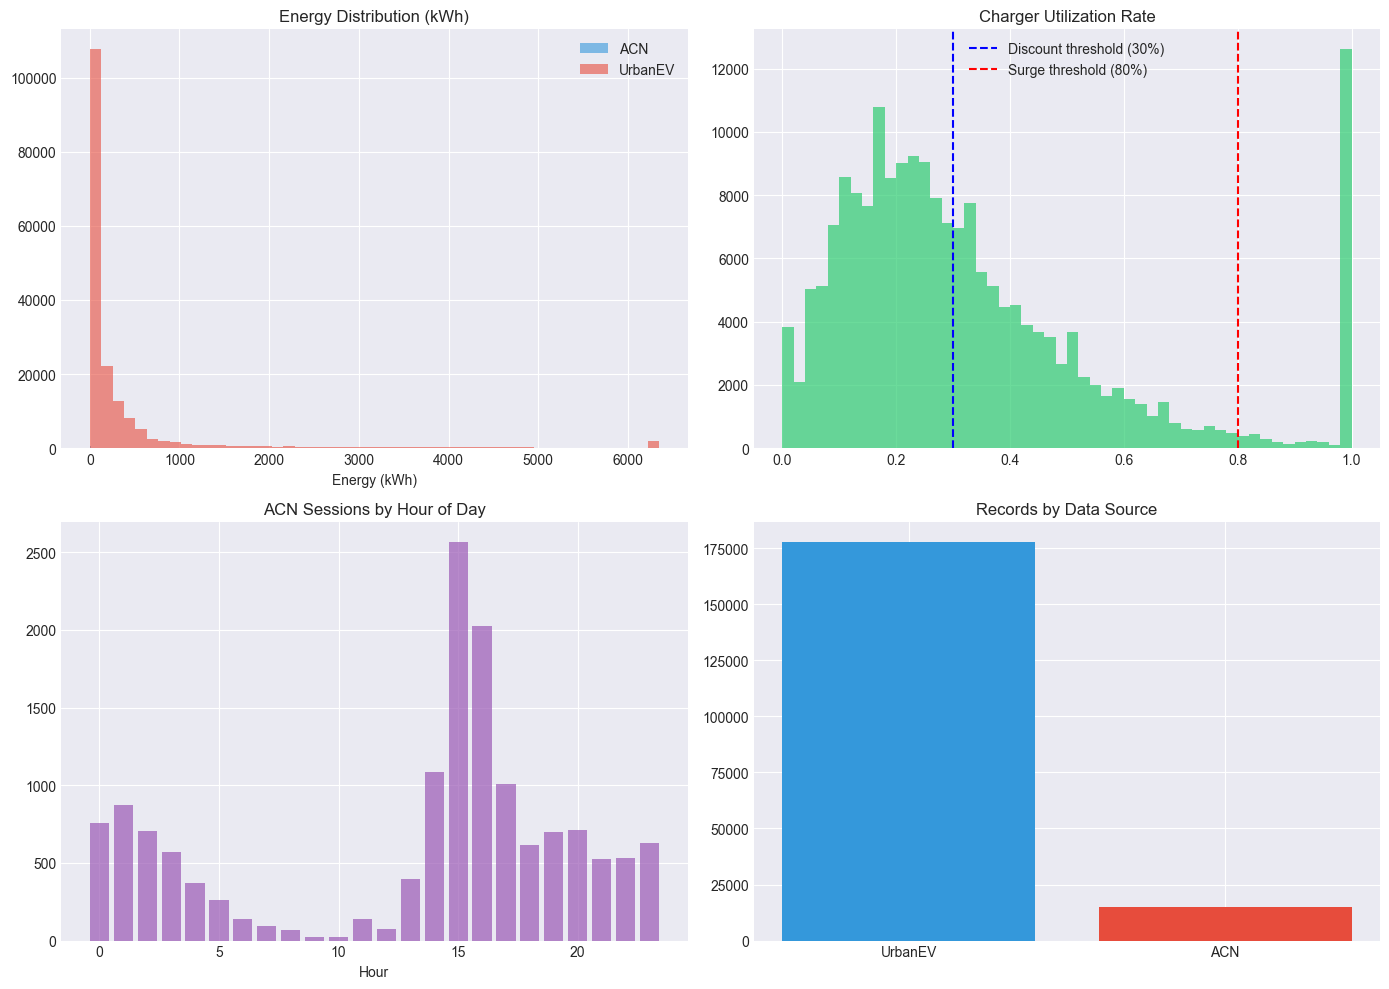

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Energy distribution by source
for src, color in [("ACN", "#3498db"), ("UrbanEV", "#e74c3c")]:
    subset = merged[merged["data_source"] == src]["energy_kwh"].dropna()
    if not subset.empty:
        axes[0, 0].hist(subset.clip(0, subset.quantile(0.99)), bins=50, alpha=0.6, label=src, color=color)
axes[0, 0].set_title("Energy Distribution (kWh)")
axes[0, 0].set_xlabel("Energy (kWh)")
axes[0, 0].legend()

# Utilization distribution
util = merged["charger_utilization_rate"].dropna()
if not util.empty:
    axes[0, 1].hist(util, bins=50, color="#2ecc71", alpha=0.7)
    axes[0, 1].axvline(0.3, color="blue", ls="--", label="Discount threshold (30%)")
    axes[0, 1].axvline(0.8, color="red", ls="--", label="Surge threshold (80%)")
    axes[0, 1].set_title("Charger Utilization Rate")
    axes[0, 1].legend()

# Hourly session count (ACN only)
acn_subset = merged[merged["data_source"] == "ACN"]
if "timestamp" in acn_subset.columns:
    ts = pd.to_datetime(acn_subset["timestamp"])
    hourly_counts = ts.dt.hour.value_counts().sort_index()
    axes[1, 0].bar(hourly_counts.index, hourly_counts.values, color="#9b59b6", alpha=0.7)
    axes[1, 0].set_title("ACN Sessions by Hour of Day")
    axes[1, 0].set_xlabel("Hour")

# Records by source
source_counts = merged["data_source"].value_counts()
axes[1, 1].bar(source_counts.index, source_counts.values, color=["#3498db", "#e74c3c"])
axes[1, 1].set_title("Records by Data Source")

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "preprocessing_validation.png"), dpi=150, bbox_inches="tight")
plt.show()

## Engineering Decisions and Assumptions Log

| Decision | Rationale |
|----------|-----------|
| Dropped sessions with missing kWhDelivered | Cannot compute revenue without energy data |
| Dropped sessions with duration ≤ 0 | Invalid data (negative time) |
| Forward-filled UrbanEV missing intervals | Assume charging state persists until next observation |
| Aligned to 1-hour granularity | Balances granularity and data density for both datasets |
| Used grid IDs as station_id for UrbanEV | Each grid represents a cluster of charging piles |
| Prefixed UrbanEV station IDs with "UV_" | Avoids ID collision with ACN station IDs |
| UrbanEV utilization = active_chargers / total_chargers | Direct measurement from occupancy data |
| ACN utilization ≈ charging_min × sessions / 60 | Proxy since we don't have real-time occupancy |